# Age, Sex, Consumption and Cancer: A Support Vector Machine Approach
### Name: Duong Le
### Due: 26 April 2026

# Table of Content

[Introduction](#Introduction)

[Theoretical Background](#Theoretical-Background)

[Methodology](#Methodology)

* [Preprocessing](#Preprocessing)

* [Optimal Kernel](#Optimal-Kernel)

* [Comparison and Evaluation](#Comparison-and-Evaluation)

* [Result Plots](#Result-Plots)

[Further discussion](#Further-discussion)

[Limitations](#Limitations)

[Conclusion](#Conclusion)

[References](#References)


# Introduction 

This project aims to investigate the relationship between demographics, diet and the prevalence of major chronic diseases (specifically cancer) using Support Vector Machines (SVMs). By comparing multiple SVM kernels (including linear, polynomial, and radial basis function), this analysis evaluates how well different model specifications capture complex, potentially nonlinear relationships in health-related data.

The dataset used in this analysis originates from the 2022 National Health Interview Survey (NHIS), a large-scale, nationally representative survey conducted to monitor the health of the U.S. population. The data was accessed through IPUMS Health Surveys. The dataset includes variables capturing respondent demographics, five major health conditions (cancer, heart disease, diabetes, heart attack, and stroke), and a wide range of behavioral and lifestyle factors such as work hours, physical activity, sleep duration, and dietary habits. This rich combination of variables enables a comprehensive exploration of how everyday behaviors and demographic factors relate to disease outcomes.

# Theoretical Background

Support Vector Machines (SVMs) are supervised learning algorithms used for classification tasks that aim to identify an optimal decision boundary, or hyperplane, that maximally separates classes in feature space. The key idea behind SVMs is margin maximization, where the algorithm seeks to maximize the distance between the separating hyperplane and the closest data points from each class, known as support vectors. When data is not linearly separable, kernel functions are used to project the data into higher-dimensional spaces where separation becomes possible.

Three kernel types are commonly used: linear, polynomial, and radial basis function (RBF). The linear kernel assumes a linear relationship between features and the target, while the polynomial kernel introduces interaction terms and nonlinear boundaries based on a specified degree. The RBF kernel is a highly flexible, nonlinear kernel that maps data into an infinite-dimensional space, allowing it to capture complex patterns.

Key hyperparameters include the regularization parameter C, which controls the trade-off between maximizing the margin and minimizing classification error, and γ, which determines the influence of individual training points in nonlinear kernels. Model performance is evaluated using metrics such as accuracy, precision, recall, F1-score, and the area under the Receiver Operating Characteristic curve (ROC-AUC), with particular emphasis on metrics robust to class imbalance.

# Methodology

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplots, cm
from matplotlib import pyplot as plt
from ISLP import load_data, confusion_table
from ISLP.svm import plot as plot_svm
from sklearn.impute import SimpleImputer
import sklearn.model_selection as skm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, auc, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.inspection import DecisionBoundaryDisplay

## Preprocessing 

Variables were manually pre-selected before being loaded. This is to ensure that the scope stays within disease markers, some demographics information, and food habits. There are 18 variables and 35,115 rows. 

In [26]:
df = pd.read_csv("nhis.csv")

In [27]:
df

,ASTATFLG,CSTATFLG,AGE,SEX,HOURSWRK,CANCEREV,CHEARTDIEV,DIABETICEV,HEARTATTEV,STROKEV,ALCDAYSYR,JUICEMNO,SALSAMNO,TOMSAUCEMNO,SPORDRMNO,FRTDRINKMNO,COFETEAMNO,HRSLEEP
0,1,0,61,1,45,1,1,1,1,1,104,0,5,2,3,0,0,8
1,1,0,43,1,45,1,1,1,1,1,52,1,1,1,0,0,1,6
2,0,1,12,2,0,0,0,1,0,0,996,996,996,996,996,996,996,0
3,1,0,68,1,0,1,1,1,1,1,364,0,2,1,0,2,0,6
4,1,0,73,1,0,1,1,1,1,1,0,0,0,3,1,0,30,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35110,0,1,11,1,0,0,0,1,0,0,996,996,996,996,996,996,996,0
35111,1,0,18,1,0,1,1,1,1,1,2,3,1,1,2,0,2,7
35112,0,1,12,2,0,0,0,1,0,0,996,996,996,996,996,996,996,0
35113,1,0,61,2,0,1,1,1,1,1,0,10,1,3,0,0,0,5


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35115 entries, 0 to 35114
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ASTATFLG     35115 non-null  int64
 1   CSTATFLG     35115 non-null  int64
 2   AGE          35115 non-null  int64
 3   SEX          35115 non-null  int64
 4   HOURSWRK     35115 non-null  int64
 5   CANCEREV     35115 non-null  int64
 6   CHEARTDIEV   35115 non-null  int64
 7   DIABETICEV   35115 non-null  int64
 8   HEARTATTEV   35115 non-null  int64
 9   STROKEV      35115 non-null  int64
 10  ALCDAYSYR    35115 non-null  int64
 11  JUICEMNO     35115 non-null  int64
 12  SALSAMNO     35115 non-null  int64
 13  TOMSAUCEMNO  35115 non-null  int64
 14  SPORDRMNO    35115 non-null  int64
 15  FRTDRINKMNO  35115 non-null  int64
 16  COFETEAMNO   35115 non-null  int64
 17  HRSLEEP      35115 non-null  int64
dtypes: int64(18)
memory usage: 4.8 MB


### Variable encoding
All variables used in the analysis were encoded numerically to ensure compatibility with SVM models. Binary variables were represented using 0/1 encoding, while continuous variables were retained in their numeric form. No nominal categorical variables requiring one-hot encoding were included in the final dataset.

In [32]:
# Recoding data + establishing NAs
df.loc[df['AGE'] > 99, 'AGE'] = np.nan
df.loc[~df['SEX'].isin([1, 2]), 'SEX'] = np.nan
df['HOURSWRK'] = df['HOURSWRK'].replace({97: np.nan, 98: np.nan, 99: np.nan})
df.loc[df['ALCDAYSYR'] > 365, 'ALCDAYSYR'] = np.nan

def recode_binary(col):
    return col.replace({0: np.nan, 7: np.nan, 8: np.nan, 9: np.nan, 1: 0, 2: 1})
df['CANCEREV'] = recode_binary(df['CANCEREV'])
df['CHEARTDIEV'] = recode_binary(df['CHEARTDIEV'])
df['DIABETICEV'] = recode_binary(df['DIABETICEV'])
df['HEARTATTEV'] = recode_binary(df['HEARTATTEV'])
df['STROKEV'] = recode_binary(df['STROKEV'])

food_na = {996: np.nan, 997: np.nan, 998: np.nan, 999: np.nan}
cols_food = ['ALCDAYSYR', 'JUICEMNO', 'COFETEAMNO','SALSAMNO', 'TOMSAUCEMNO','SPORDRMNO', 'FRTDRINKMNO']
for col in cols_food:
    df[col] = df[col].replace(food_na)
df['HRSLEEP'] = df['HRSLEEP'].replace({25: 0, 97: np.nan, 98: np.nan, 99: np.nan})

### Understanding systematic missingness

An analysis was conducted to assess whether missing values occurred systematically or at random. For each pair of variables, the difference in missingness rates across grouped categories was computed. Only pairs with a difference of at least 0.05 were retained.

The results revealed substantial evidence of non-random missingness, with differences ranging from 0.05 to 1.00 across 84 variable combinations. Notably, variables such as age and sleep duration frequently appeared as grouping variables associated with large differences in missingness of other predictors. In extreme cases, such as the relationship between sleep duration and coffee/tea consumption frequency, missingness differed by 100 percentage points across groups, indicating deterministic or near-deterministic patterns.

In [33]:
def missingness_analysis(df, threshold=0.05):
    results = []

    cols = df.columns

    for target in cols:
        if df[target].nunique() <= 1:
            continue 

        for predictor in cols:
            if target == predictor:
                continue

            grouped = df.groupby(target)[predictor].apply(lambda x: x.isna().mean())

            if len(grouped) < 2:
                continue

            diff = grouped.max() - grouped.min()

            if diff >= threshold:
                results.append({
                    'target': target,
                    'predictor': predictor,
                    'missingness_diff': round(diff, 2)})

    results_df = pd.DataFrame(results).sort_values(by='missingness_diff', ascending=False)

    return results_df

missing_patterns = missingness_analysis(df, threshold=0.05)
print(missing_patterns.head(20))

         target    predictor  missingness_diff
0      ASTATFLG     CANCEREV               1.0
22          AGE     CANCEREV               1.0
24          AGE   HEARTATTEV               1.0
25          AGE      STROKEV               1.0
39     HOURSWRK    ALCDAYSYR               1.0
1      ASTATFLG   CHEARTDIEV               1.0
65  TOMSAUCEMNO      HRSLEEP               1.0
67  FRTDRINKMNO    ALCDAYSYR               1.0
70   COFETEAMNO    ALCDAYSYR               1.0
71      HRSLEEP     CANCEREV               1.0
72      HRSLEEP   CHEARTDIEV               1.0
74      HRSLEEP   HEARTATTEV               1.0
75      HRSLEEP      STROKEV               1.0
76      HRSLEEP    ALCDAYSYR               1.0
77      HRSLEEP     JUICEMNO               1.0
78      HRSLEEP     SALSAMNO               1.0
79      HRSLEEP  TOMSAUCEMNO               1.0
80      HRSLEEP    SPORDRMNO               1.0
81      HRSLEEP  FRTDRINKMNO               1.0
23          AGE   CHEARTDIEV               1.0


## Establish datasets

Five disease-specific datasets were constructed to enable independent modeling of each health outcome. For each disease, rows with missing target values were removed while all remaining predictor variables were retained to maximize sample size and avoid unnecessary data loss. Missing values in predictor variables were handled using median imputation, which was selected for its robustness to skewed distributions commonly observed in health survey data. This approach preserves the central tendency of each variable without being influenced by outliers. Creating separate datasets for each disease allows each model to use all available labeled observations, or to change target disease if the data quality for one is not optimal for modelling (later, if needed)

In [47]:
targets = ['CANCEREV', 'CHEARTDIEV', 'DIABETICEV', 'HEARTATTEV', 'STROKEV']

dfs = {}

for target in targets:
    df_model = df.copy()
    
    # Drop rows where this target is missing
    df_model = df_model[df_model[target].notna()]
    
    # Drop other target variables
    other_targets = [t for t in targets if t != target]
    df_model = df_model.drop(columns=other_targets)
    
    # Separate X and y
    X = df_model.drop(columns=[target])
    y = df_model[target]
    
    # Impute predictors
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    
    X_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)
    
    # Store as dictionary
    dfs[target] = {'X': X_imputed, 'y': y}

The cancer dataset has 27,614 rows and 13 variables, post-imputation. 

In [43]:
# Example usage
X_cancer, y_cancer = dfs['CANCEREV']
print(X_cancer.shape, y_cancer.shape)

(27614, 13) (27614,)


## EDA Visualizations

The exploratory analysis revealed substantial class imbalance across both outcome and predictor variables. For all five disease outcomes, the majority of respondents reported not having the condition, resulting in heavily skewed binary targets. Similar imbalance was observed among several behavioral predictors, for instance consumption of food and drinks. In contrast, demographic variables such as sex and age exhibited relatively balanced distributions, with adequate representation across categories. This imbalance has important implications for modeling, as it may bias classifiers toward the majority class and reduce sensitivity to minority outcomes. Therefore, evaluation metrics beyond accuracy, such as F1-score, and the use of class weighting in SVM models are necessary in performance assessment.

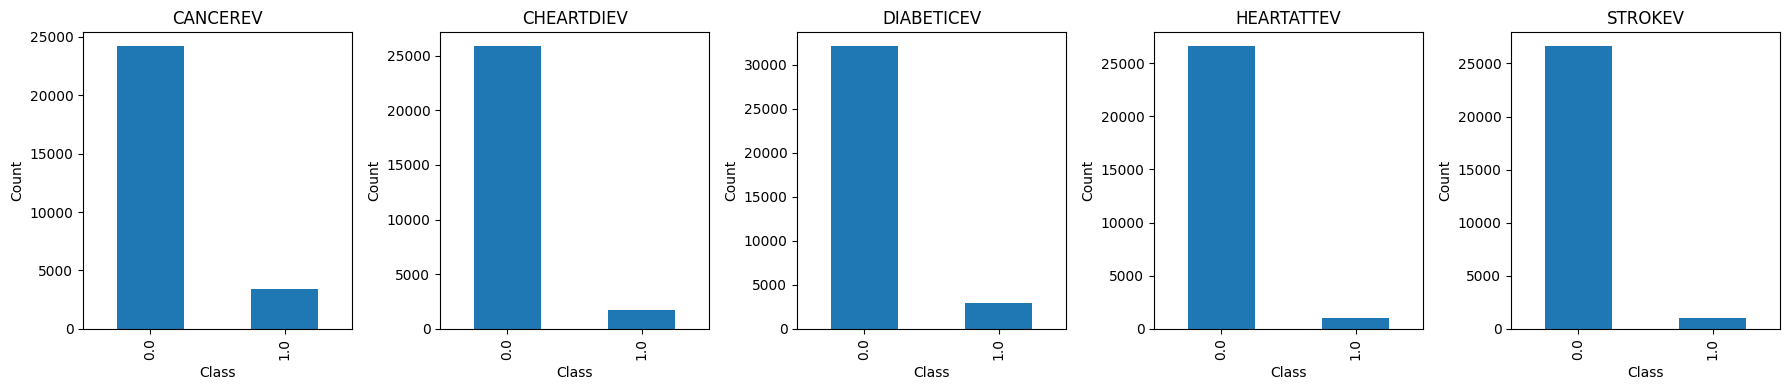

In [36]:
fig, axes = plt.subplots(1, len(targets), figsize=(18, 4))

for i, col in enumerate(targets):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

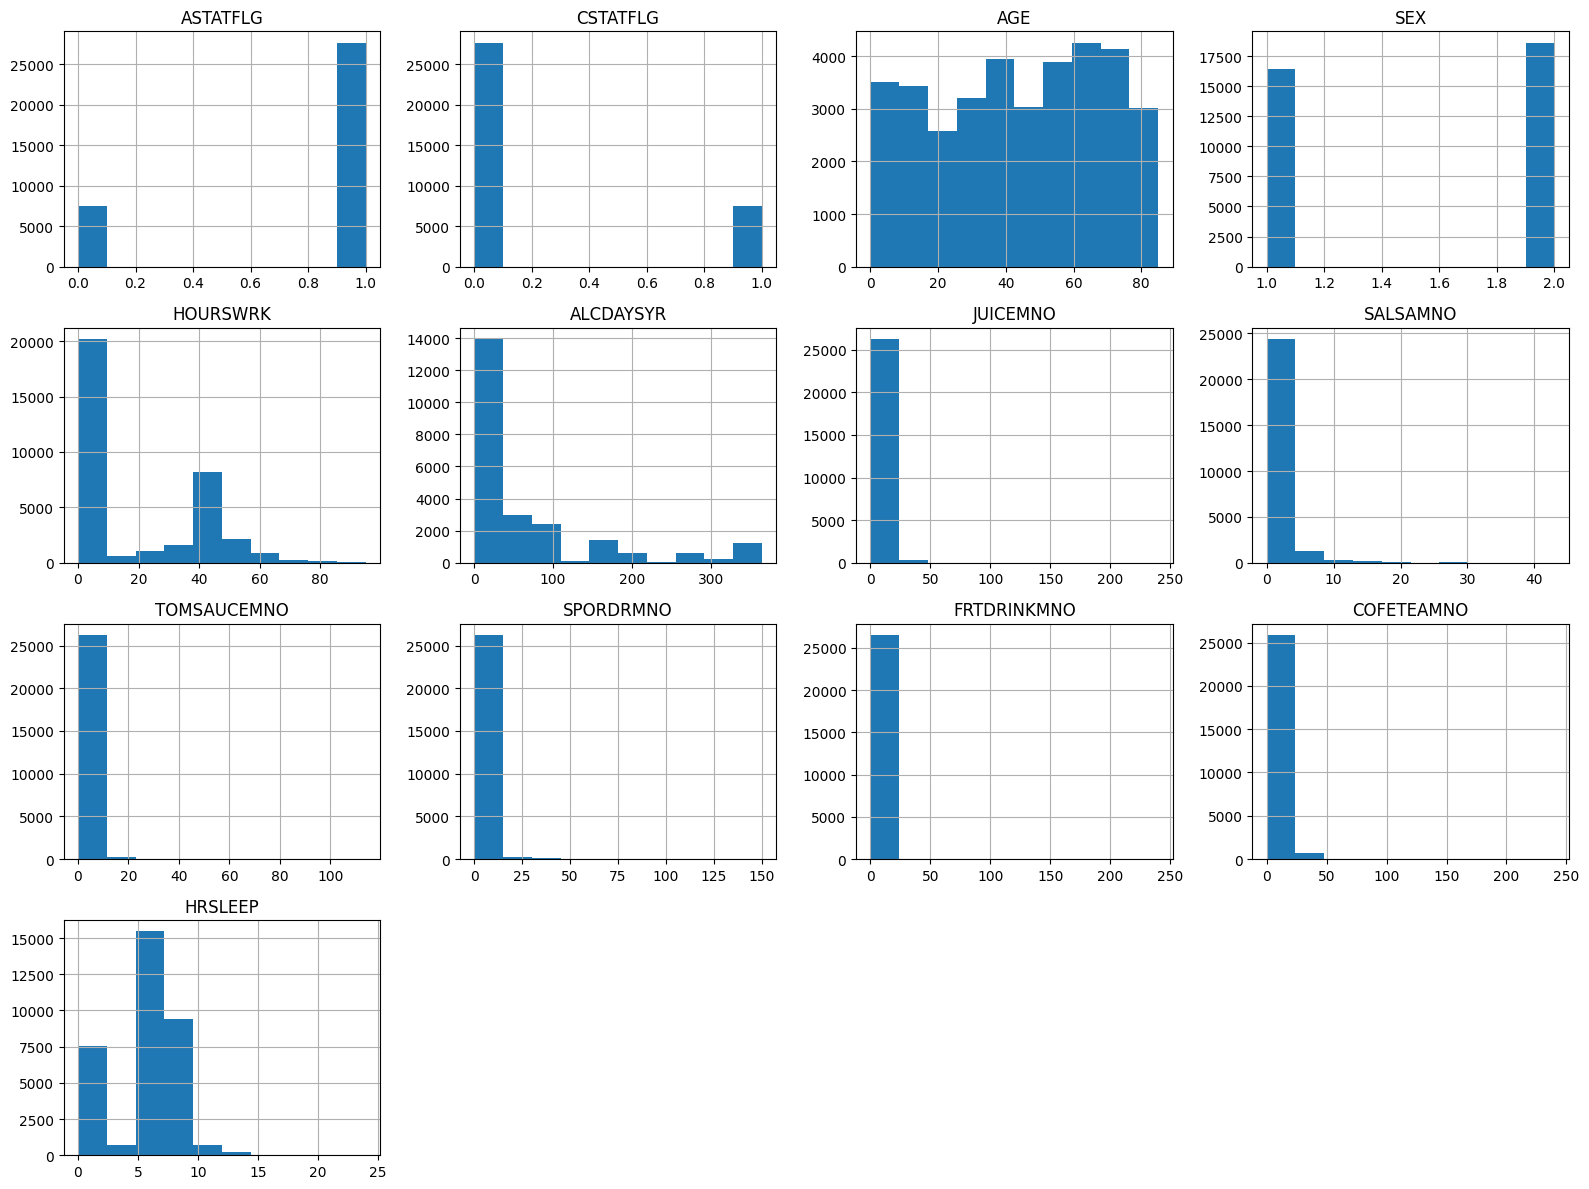

In [37]:
df.drop(columns=targets).hist(figsize=(16, 12))
plt.tight_layout()
plt.show()

# Models

Three SVM models were implemented using different kernel functions: linear, polynomial, and radial basis function (RBF). Each model was trained using a stratified train-test split (70/30) to preserve class distribution. To address class imbalance, class weights were set to “balanced,” ensuring that minority class observations were appropriately weighted during model training.

Hyperparameter tuning was conducted using GridSearchCV with cross-validation. For each kernel, a predefined grid of parameters was evaluated, including values of the regularization parameter C, kernel-specific parameters such as degree (for polynomial), and gamma (for nonlinear kernels). A 5-fold cross-validation procedure was used to estimate model performance and select optimal parameter combinations based on the F1-score, rather than accuracy alone.

Model performance was evaluated using multiple metrics, including accuracy, precision, recall, F1-score, and ROC-AUC. Confusion matrices were also analyzed to better understand classification errors, particularly false negatives.

In [48]:
# Scale data
X = dfs['CANCEREV']['X']
y = dfs['CANCEREV']['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.3,stratify=y,random_state=42)

In [50]:
# Linear kernel
linear_grid = {'C': [0.1, 1, 10]}

grid_linear = GridSearchCV(SVC(kernel='linear', class_weight='balanced'),linear_grid,cv=3,scoring='f1',n_jobs=-1)

grid_linear.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(class_weight='balanced', kernel='linear'),
             n_jobs=-1, param_grid={'C': [0.1, 1, 10]}, scoring='f1')

In [51]:
# Poly kernel
poly_grid = {'C': [0.1, 1],'degree': [2, 3],'gamma': ['scale']}

grid_poly = GridSearchCV(SVC(kernel='poly', class_weight='balanced'),poly_grid,cv=3,scoring='f1',n_jobs=-1)

grid_poly.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(class_weight='balanced', kernel='poly'),
             n_jobs=-1,
             param_grid={'C': [0.1, 1], 'degree': [2, 3], 'gamma': ['scale']},
             scoring='f1')

In [52]:
# RBF
rbf_grid = {'C': [0.1, 1, 10],'gamma': ['scale']}

grid_rbf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'),rbf_grid,cv=3,scoring='f1',n_jobs=-1)

grid_rbf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale']}, scoring='f1')

## Optimal Kernel

The optimal kernel is poly. Firstly, it has the best test accuracy of 67.9%. Secondly, it is able to catch the most true positives. Finally, it generalizes the best out of the three, as shown by the identical train and test accuracy. 


In [53]:
results = {'linear': grid_linear.best_score_,'poly': grid_poly.best_score_,'rbf': grid_rbf.best_score_}

best_kernel = max(results, key=results.get)

print("Scores:", results)
print("Best kernel:", best_kernel)

Scores: {'linear': 0.36714288889545593, 'poly': 0.3704180454601693, 'rbf': 0.3614869270785534}
Best kernel: poly


In [54]:
best_model = {'linear': grid_linear,'poly': grid_poly,'rbf': grid_rbf}[best_kernel]

y_pred = best_model.predict(X_test)

## Comparison and Evaluation

All three kernel models are only modest performers. Accuracy ranges from 66–68%, and the ROC-AUC ranges from 0.776 to 0.787. The poly kernel edges out the others slightly. The class imbalance problem is the most critical issue. The dataset has roughly 7:1 class imbalance. All three models learned to exploit this: they predict class 0 (no cancer) with 96% precision but only catch about 64–66% of actual negatives, while performing much worse on the cancer-positive class (class 1), with precision of only ~0.24–0.25.For cancer diagnosis specifically, recall on class 1 is what matters most. A false negative (missing a real cancer) is far more dangerous than a false positive. RBF actually has the highest recall for class 1 (0.81), matching poly, while linear is close behind.

In [57]:
models = {'linear': grid_linear.best_estimator_,'poly': grid_poly.best_estimator_,'rbf': grid_rbf.best_estimator_}
results = {}

for name, model in models.items():
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_test_prob = model.decision_function(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_prob)
    
    print(f"\n===== {name.upper()} =====")
    print("Train Accuracy:", round(train_acc, 3))
    print("Test Accuracy:", round(test_acc, 3))
    print("ROC-AUC:", round(roc_auc, 3))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    
    results[name] = {'train_acc': train_acc,'test_acc': test_acc,'roc_auc': roc_auc}


===== LINEAR =====
Train Accuracy: 0.665
Test Accuracy: 0.671
ROC-AUC: 0.787

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.65      0.78      7256
         1.0       0.25      0.81      0.38      1029

    accuracy                           0.67      8285
   macro avg       0.60      0.73      0.58      8285
weighted avg       0.87      0.67      0.73      8285

Confusion Matrix:
[[4725 2531]
 [ 198  831]]

===== POLY =====
Train Accuracy: 0.679
Test Accuracy: 0.679
ROC-AUC: 0.781

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.66      0.78      7256
         1.0       0.25      0.79      0.38      1029

    accuracy                           0.68      8285
   macro avg       0.60      0.73      0.58      8285
weighted avg       0.87      0.68      0.73      8285

Confusion Matrix:
[[4815 2441]
 [ 215  814]]

===== RBF =====
Train Accuracy: 0.666
Test Accuracy: 

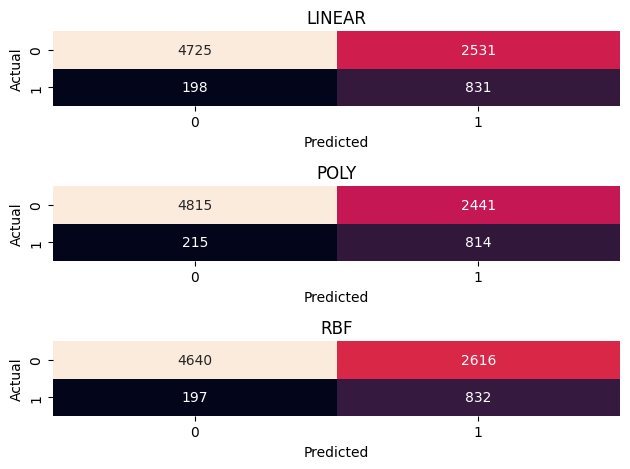

In [62]:
fig, axes = plt.subplots(3,1)

for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cbar=False)
    axes[i].set_title(name.upper())
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Result Plots

|          | Linear     | Polynomial     | Radial    |
|----------|------------|-----------------|----------------|
|**Train accuracy**| 0.665 | 0.679 | 0.686|
|**Test accuracy**| 0.671 | 0.679 | 0.660 |
|**Precision (Class 1)**| 0.25 | 0.25 | 0.24 |
|**Recall (Class 1)**| 0.81 | 0.79 | 0.81 |
|**F1-score (Class 1)**|0.38 | 0.38 | 0.37 |
|**ROC-AUC**| 0/787| 0.781 | 0.776 |


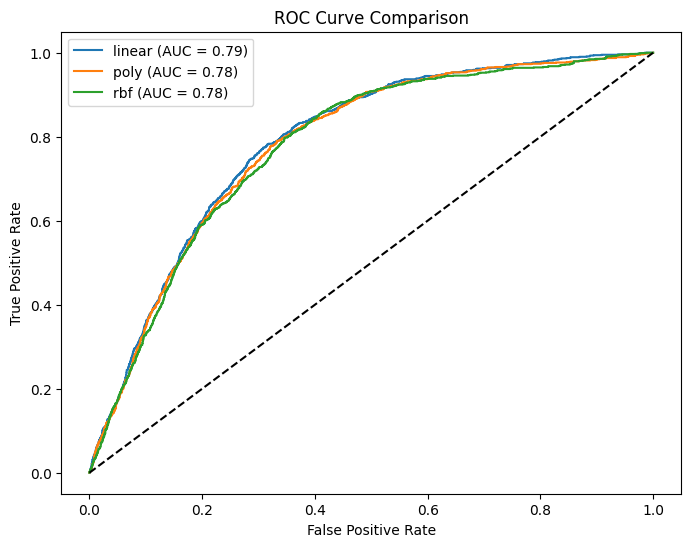

In [66]:
# ROC cruve
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

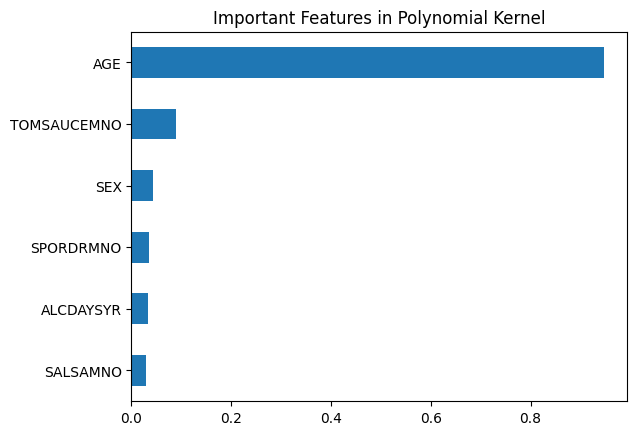

In [69]:
# Feature importance
coef = models['linear'].coef_[0]
features = X.columns

importance = pd.Series(coef, index=features).sort_values()

importance.tail(6).plot(kind='barh', title="Important Features in Polynomial Kernel")
plt.show()

In [2]:
# In progress:
# decision boundary plot
# still debugging issue boundary not showing on plot + plot take a really long time to run
# might have to subsample

# Discussion 

There is relatively consistent performance across linear, polynomial, and RBF kernels, with only marginal differences in accuracy and ROC-AUC. The polynomial kernel achieved the highest test accuracy (0.679), while the linear kernel slightly outperformed others in ROC-AUC (0.787). However, these differences are minimal, suggesting that the underlying relationships between predictors and cancer outcomes may not be strongly nonlinear, or that the available features do not provide sufficient signal for more complex kernels to significantly improve performance.

A closer look at classification metrics highlights a key challenge: class imbalance. While all models achieved high precision for the negative class (0.96), precision for the positive class (cancer cases) remained low (0.24–0.25). In contrast, recall for the positive class was relatively high (0.79–0.81), indicating that the models were effective at identifying most cancer cases but at the cost of a high number of false positives. This trade-off is reflected in the confusion matrices, where false positives are substantial across all kernels. From a public health perspective, this behavior may still be acceptable, as identifying potential cases (even with some false alarms) is often preferable to missing true cases.

Age overwhelmingly dominates the model (importance 0.87), confirming its well-established role as a primary risk factor for cancer. Secondary contributors include tomato sauce consumption (0.11) and sex (0.06), suggesting that both dietary and demographic factors play a modest role. Smaller positive contributions from sports drink and alcohol consumption (0.02) indicate weak associations.

Interestingly, the similarity in performance across kernels, combined with the dominance of a single feature (age), suggests that the model is largely driven by a strong, simple signal rather than complex nonlinear interactions. This may explain why more flexible kernels such as RBF did not yield substantial improvements over the linear baseline.

# Conclusion

This project is a study on how Support Vector Machines can use demographic and behavioral data to predict cancer outcomes, though performance is constrained by class imbalance and limited feature signal. Across all kernel types, the models achieved moderate predictive performance, with ROC-AUC values around 0.78, indicating reasonable discrimination between classes.

A key finding is the overwhelming influence of age as a predictor, reinforcing its central role in cancer risk assessment. While additional variables such as tomato sauce and sports drinks consumption contributed marginally, their effects were comparatively small, suggesting that either these factors are weak predictors in isolation or that their relationships with cancer are more complex than can be captured by the current feature set.

From an applied perspective, the models’ high recall for cancer cases suggests potential usefulness in screening contexts, where identifying as many at-risk individuals as possible is critical. However, the low precision highlights the risk of false positives, which could lead to unnecessary follow-up if deployed in practice.

Future work could improve upon these results by incorporating richer feature sets, exploring alternative modeling approaches such as ensemble methods, or applying more advanced techniques to address class imbalance. Additionally, longitudinal data could provide deeper insights into causal relationships and improve predictive performance. 

# References

Lynn A. Blewett, Julia A. Rivera Drew, Miriam L. King, Kari C.W. Williams, Daniel Backman, Annie Chen, and Stephanie Richards. IPUMS Health Surveys: National Health Interview Survey, Version 7.4 [dataset]. Minneapolis, MN: IPUMS, 2024. https://doi.org/10.18128/D070.V7.4

Missing data and multiple imputation. Columbia University Mailman School of Public Health. (2022, October 3). https://www.publichealth.columbia.edu/research/population-health-methods/missing-data-and-multiple-imputation 

GeeksforGeeks. (2025, July 23). Compute Classification Report and confusion matrix in Python. https://www.geeksforgeeks.org/machine-learning/compute-classification-report-and-confusion-matrix-in-python/ 

Projects day poster tips and tricks. Seattle University. (n.d.). https://www.seattleu.edu/science-engineering/project-center/student-resources/projects-day-poster-tips-and-tricks/ 

Krython. (n.d.). model evaluation: Metrics and validation - tutorial. https://krython.com/tutorial/python/model-evaluation-metrics-and-validation/ 

Python machine learning: Scikit-learn tutorial | datacamp. (n.d.). https://www.datacamp.com/tutorial/machine-learning-python 